# A notebook for testing, saving, and every kind of random stuff

In [1]:
import numpy as np
from dataset_generator.data_generator import *
from utils.other_utils import *
import matplotlib.pyplot as plt
import os
from tqdm import tqdm



# model
from model.CTRNN import *
from easydict import EasyDict as edict
import yaml
from utils.train_helper import load_model

## cue data generator

In [6]:
number_of_data_samples = 500
data_duration = 30
cue_first_time = 10
cue_last_time = 20
sine_length = 5
sine_amplitude = 1
dt = 0.01

In [5]:
all_data = []
for i in range(number_of_data_samples):
    data_x, data_y, cue_idx, sine_last_idx = cue_signal_generator(data_duration,
                                                                  cue_first_time,
                                                                  cue_last_time,
                                                                  sine_length,
                                                                  sine_amplitude,
                                                                  dt)
    data = {'data_x': data_x,
            'data_y': data_y,
            'cue_idx': cue_idx,
            'sine_last_idx': sine_last_idx,
            'dt': dt}

    all_data.append(data)

In [20]:
path_to_save = '/home/matin/McMaster/trimba/phd_codes/ctrnn/pytorch/generated_datasets'
# data_name = 'cue_f5_l12_sl5_sa1_dt01'
data_name = 'samples_500_duration_30_dt01_cue_f10_l20_sl5_sa1'
save(path_to_save, data_name, all_data)

1

## test data loader

In [2]:
from torch.utils.data import SubsetRandomSampler
import torch.utils.data
from dataset.cue_data import *

In [3]:
class config:
    class dataset:
        path_to_data = '/home/matin/McMaster/trimba/phd_codes/ctrnn/pytorch/generated_datasets/cue_f5_l12_sl5_sa1_dt01.pkl'
        input_transform = None
        target_transform = None
    pass

In [4]:
conf = config
data_set = CueData(conf)

In [5]:
train_loader = torch.utils.data.DataLoader(
    data_set,
    batch_size=10,
    num_workers=0)

In [6]:
data_x, data_y, cue_idx, sine_last_idx = next(iter(train_loader))

In [17]:
len(data_x)

10

In [18]:
cue_idx

tensor([ 640, 1022,  739,  985, 1195, 1198, 1131,  919,  520,  652])

## test cue trained model

### data

In [46]:
number_of_data_samples = 1
data_duration = 30
cue_first_time = 10
cue_last_time = 20
sine_length = 5
sine_amplitude = 1
dt = 0.01

In [47]:
data_x, data_y, cue_idx, sine_last_idx = cue_signal_generator(data_duration,
                                                              cue_first_time,
                                                              cue_last_time,
                                                              sine_length,
                                                              sine_amplitude,
                                                              dt)

### model

In [2]:
from model.CTRNN import *
from easydict import EasyDict as edict
import yaml
from utils.train_helper import load_model

In [4]:
config_file_path = '/home/matin/McMaster/trimba/phd_codes/CTRNN/experiments/ctrnn_v0/cue/CTRNN_cue_data_2023-Jan-04-00-03-10_1139702/config.yaml'
config = edict(yaml.full_load(open(config_file_path, 'r')))

In [6]:
model = CTRNN(config)
model_file = os.path.join(config.save_dir, config.test.test_model_name)
load_model(model, model_file, config.device)

In [8]:
type(model)

model.CTRNN.CTRNN

In [143]:
activations, hidden_states, outputs = model.init_activations_outputs(batch_size=1)
outputs, activations, hidden_states = model.predict(data_x,
                                                    activations.to(config.device),
                                                    hidden_states.to(config.device),
                                                    outputs)

Text(0.5, 1.0, 'data_y')

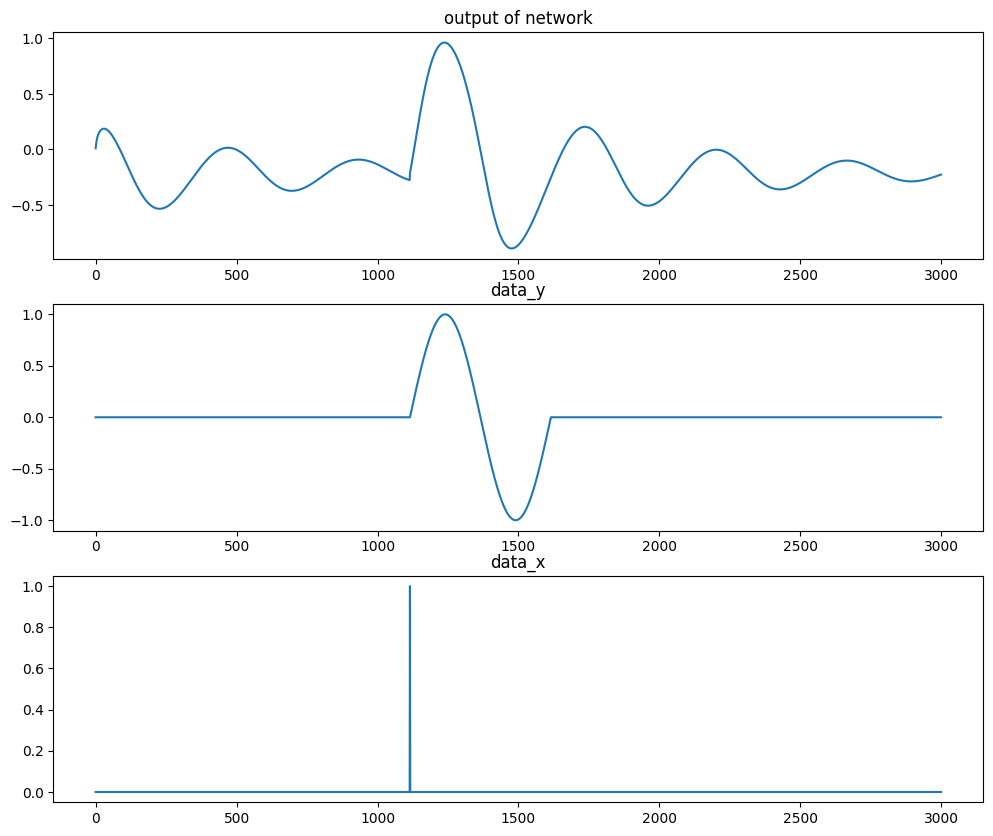

In [144]:
x_range = np.arange(3000)
_, axs = plt.subplots(3, 1, figsize=(12,10))
axs[0].plot(x_range, outputs.detach().view(3000))
axs[0].set_title('output of network')
axs[2].plot(x_range, data_x.view(3000))
axs[2].set_title('data_x')
axs[1].plot(x_range, data_y.view(3000))
axs[1].set_title('data_y')

## ready_set_go data generator

In [13]:
number_of_data_samples = 1000
data_duration = 40
first_cue_first_time = 10
first_cue_last_time = 20
min_interval = 2
max_interval = 8
sine_amplitude = 1
cue_amplitude = 0.3
dt = 0.01

In [14]:
all_data = []
for i in range(number_of_data_samples):
    data_x, data_y, first_cue_idx, second_cue_idx, sine_last_idx = ready_set_go_generator(data_duration,
                                                                                          first_cue_first_time,
                                                                                          first_cue_last_time,
                                                                                          min_interval,
                                                                                          max_interval,
                                                                                          sine_amplitude,
                                                                                          cue_amplitude,
                                                                                          dt)
    data = {'data_x': data_x,
            'data_y': data_y,
            'first_cue_idx': first_cue_idx,
            'second_cue_idx': second_cue_idx,
            'sine_last_idx': sine_last_idx,
            'dt': dt}

    all_data.append(data)

In [15]:
path_to_save = '/home/matin/trimba/phd_codes/ctrnn_pytorch/generated_datasets'
data_name = 'ready_set_go_samples_1000_duration_40_dt01_cue_f10_l20_interval_2_8_sa1_cuea3e-1'
save(path_to_save, data_name, all_data)

1

## test ready_set_go trained model

Text(0.5, 1.0, 'data_y')

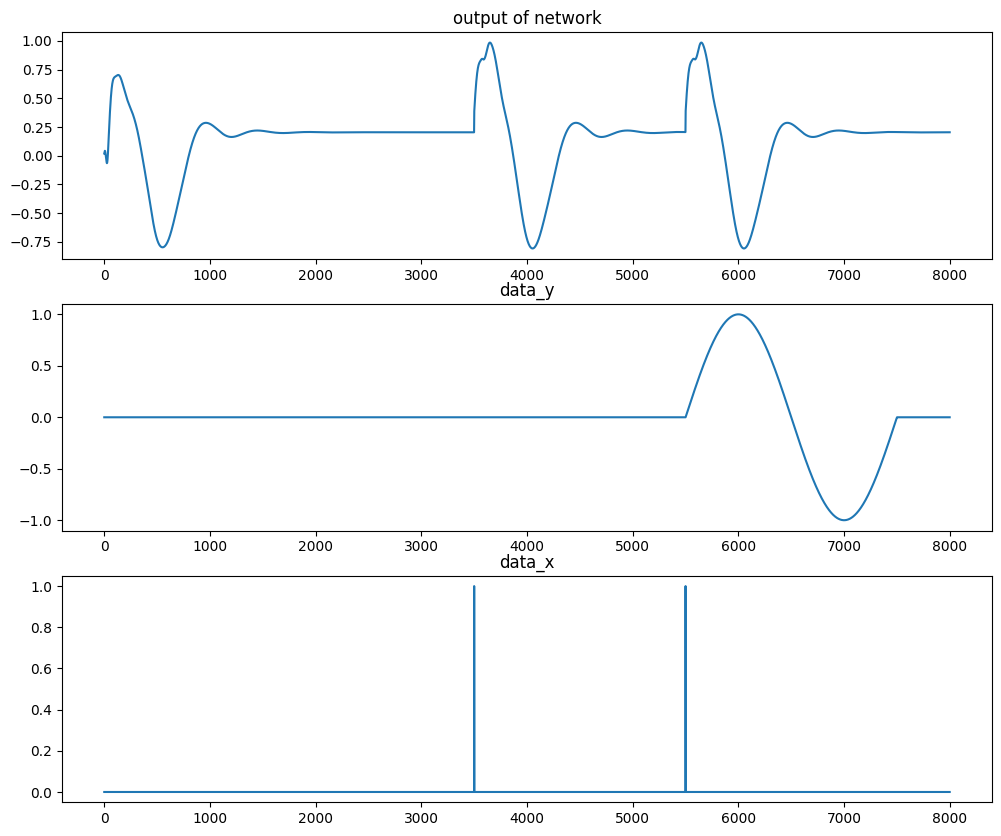

In [52]:
# data
data_duration = 80
first_cue_time = 35
second_cue_time = 55
sine_amplitude = 1
dt = 0.01
data_x, data_y, first_cue_idx, second_cue_idx, sine_last_idx = ready_set_go_forced_generator(data_duration,
                                                                                             first_cue_time,
                                                                                             second_cue_time,
                                                                                             sine_amplitude,
                                                                                             dt)


# model
from model.CTRNN import *
from easydict import EasyDict as edict
import yaml
from utils.train_helper import load_model

config_file_path = '/home/matin/trimba/phd_codes/ctrnn_pytorch/experiments/CTRNN/ready_set_go/CTRNN_ready_set_go_data_2023-Jan-11-15-39-16_544738/config.yaml'
config = edict(yaml.full_load(open(config_file_path, 'r')))
config.device = 'cpu'
model = CTRNN(config)
model_file = os.path.join(config.save_dir, config.test.test_model_name)
load_model(model, model_file, config.device)
model.to('cpu')

activations, hidden_states, outputs = model.init_activations_outputs(batch_size=1)
outputs, activations, hidden_states = model.predict(data_x,
                                                    activations.to(config.device),
                                                    hidden_states.to(config.device),
                                                    outputs)

len_data_points = int(data_duration * (1 / dt))
# plots
x_range = np.arange(len_data_points)
_, axs = plt.subplots(3, 1, figsize=(12,10))
axs[0].plot(x_range, outputs.detach().view(len_data_points))
axs[0].set_title('output of network')
axs[2].plot(x_range, data_x.view(len_data_points))
axs[2].set_title('data_x')
axs[1].plot(x_range, data_y.view(len_data_points))
axs[1].set_title('data_y')

# Testing gaussian loss function

In [25]:
dt = 0.001
x = torch.arange(10000).reshape((1, 10000)) * dt
y = scaled_gaussian_derivative_shape(x, 2, 0.4, 0.99)

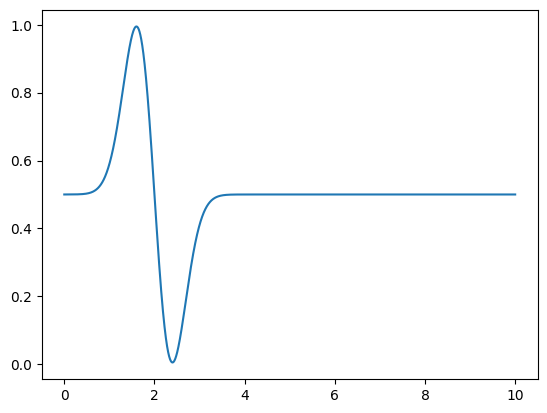

In [26]:
plt.plot(torch.flatten(x), torch.flatten(y))

# Gaussian loss function data generator


In [16]:
number_of_data_samples = 1000
data_duration = 40
first_cue_first_time = 10
first_cue_last_time = 20
min_interval = 2
max_interval = 8
variance = 0.4
scale = 0.99
cue_amplitude = 1
dt = 0.01

In [17]:
all_data = []
for i in range(number_of_data_samples):
    data_x, data_y, first_cue_idx, second_cue_idx, concavity = gaussian_derivative_loss_data(data_duration,
                                                                                             first_cue_first_time,
                                                                                             first_cue_last_time,
                                                                                             min_interval,
                                                                                             max_interval,
                                                                                             cue_amplitude,
                                                                                             variance,
                                                                                             scale,
                                                                                             dt)

    data = {'data_x': data_x,
            'data_y': data_y,
            'first_cue_idx': first_cue_idx,
            'second_cue_idx': second_cue_idx,
            'concavity_change': concavity,
            'variance': variance,
            'scale': scale,
            'dt': dt}

    all_data.append(data)

In [18]:
path_to_save = '/home/matin/McMaster/trimba/phd_codes/CTRNN/generated_datasets'
data_name = 'gaussian_loss_shape_samples_1000_duration_40_dt01_cue_f10_l20_interval_2_8_sa1_cuea1_variance0.4_scale0.99'
save(path_to_save, data_name, all_data)

1

# testing gaussian loss function

In [55]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def loss_test(x, y):
    return y*sigmoid(x) + (1-y)*(1-sigmoid(x))

In [56]:
dt = 0.001
# x = torch.arange(10000).reshape((1, 10000)) * dt
x = torch.arange(10000)*dt
y1 = scaled_gaussian_derivative_shape(x, 2, 0.4, 0.99)
y2 = scaled_gaussian_derivative_shape(x, 5, 0.6, 0.99)

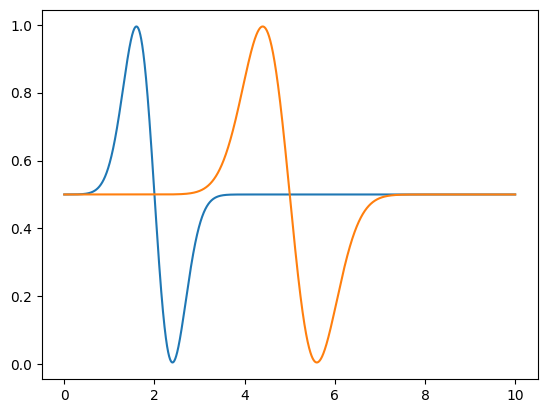

In [57]:
plt.plot(torch.flatten(x), torch.flatten(y1))
plt.plot(torch.flatten(x), torch.flatten(y2))

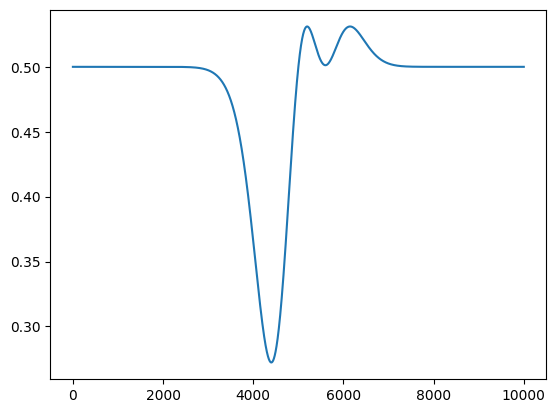

In [59]:
loss = loss_test(-y2, y2)
plt.plot(loss)

4350

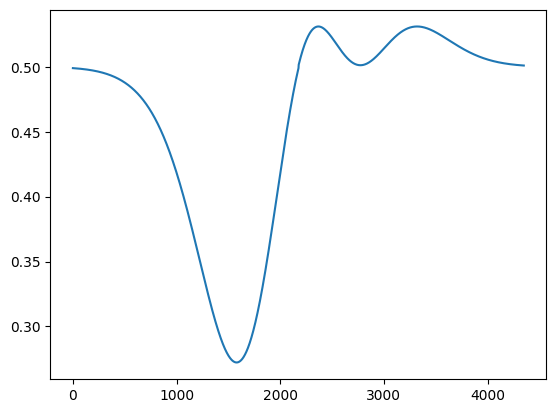

In [73]:
plt.plot(loss[torch.abs(loss - 0.50) > 0.001])

torch.sum(loss[torch.abs(loss - 0.50) > 0.001])
len(loss[torch.abs(loss - 0.50) > 0.001])

# Test triangle wave

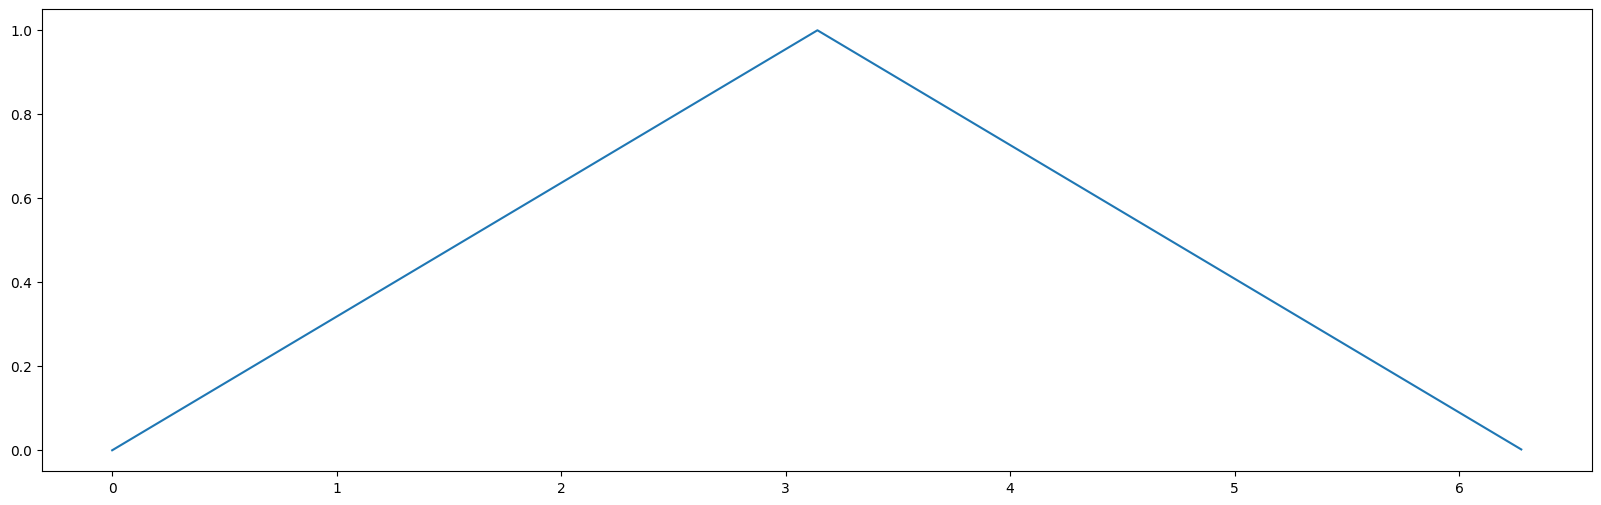

In [26]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
t = np.linspace(0, 1.8, 100)
triangle = 0.5 * (signal.sawtooth(2 * np.pi * 1/1.8 * t, 0.5) + 1)
size = 1000
dt = 0.01
t = np.arange(0, size) * 2 * np.pi / size
triangle = 0.5 * (signal.sawtooth(t, 0.5) + 1)
plt.figure(figsize=(20,6))
plt.plot(t, triangle)

# Test ready set go generator function

In [2]:
from dataset_generator.data_generator import *

In [10]:
number_of_data_samples = 1000
data_duration = 40
first_cue_first_time = 10
first_cue_last_time = 20
min_interval = 2
max_interval = 8
target_amplitude = 100
cue_amplitude = 0.3
dt = 0.01

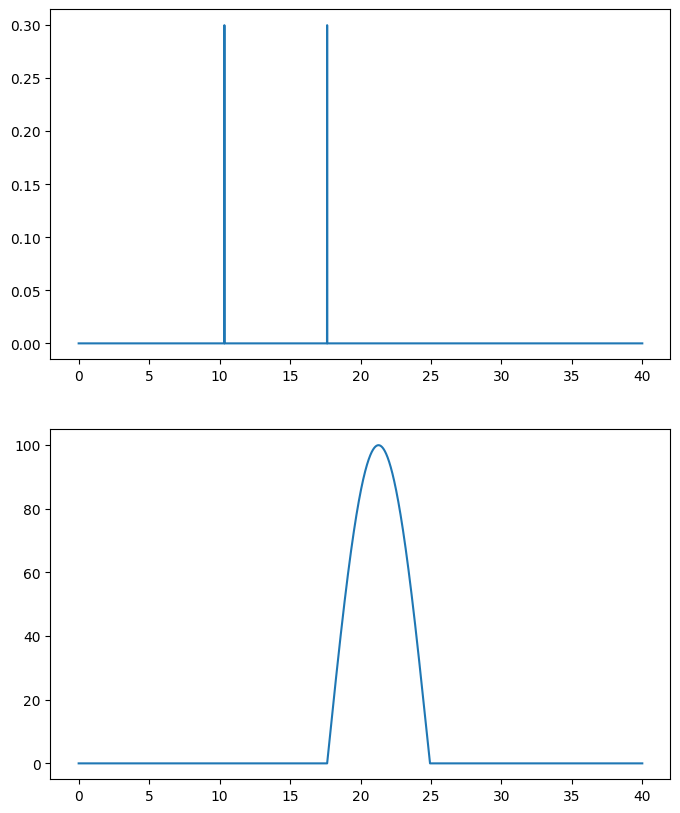

In [12]:
data_x, data_y, first_cue_idx, second_cue_idx, sine_last_idx = ready_set_go_generator('half_sine',
                                                                                      data_duration,
                                                                                      first_cue_first_time,
                                                                                      first_cue_last_time,
                                                                                      min_interval,
                                                                                      max_interval,
                                                                                      target_amplitude,
                                                                                      cue_amplitude,
                                                                                      dt)

x_range = np.arange(0, data_duration, dt)
_, axs = plt.subplots(2, 1, figsize=(8,10))
axs[0].plot(x_range, torch.flatten(data_x))
axs[1].plot(x_range, torch.flatten(data_y))

# Test ready set go generator script

In [3]:
def load(path_to_file):
    with open(path_to_file, 'rb') as file:
        rnn_params = pickle.load(file)
    return rnn_params


In [5]:
data = load('/home/matin/McMaster/trimba/phd_codes/CTRNN/generated_datasets/ready_set_go_samples_100_duration40_dt0.01_cue_f10l20_interval_2_8_targeta1_cuea1_targetshapefull_sine.pkl')

In [6]:
data[0]

{'data_x': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'data_y': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'first_cue_idx': 1146,
 'second_cue_idx': 1846,
 'sine_last_idx': 2545,
 'dt': 0.01}

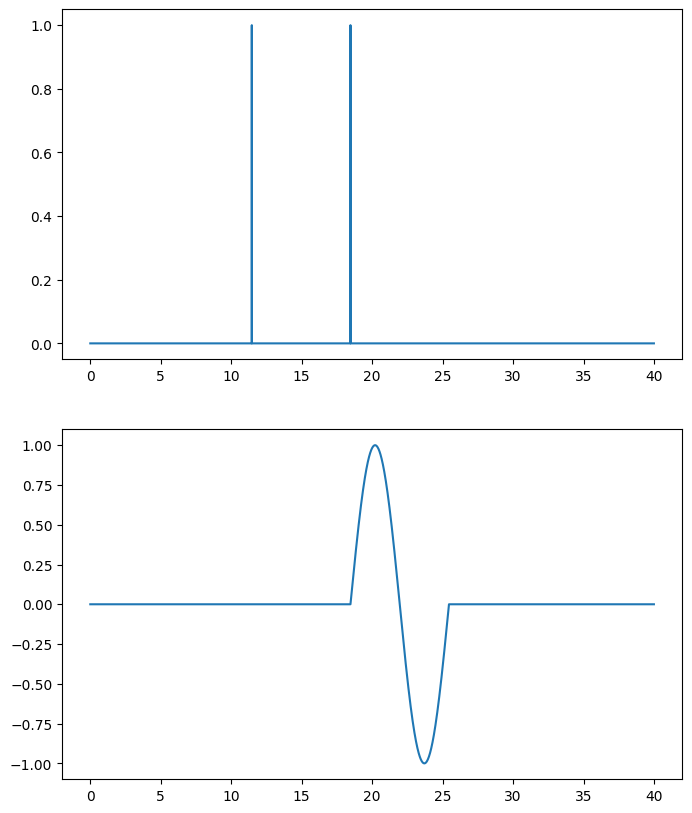

In [9]:
x_range = np.arange(0, 40, 0.01)
_, axs = plt.subplots(2, 1, figsize=(8,10))
axs[0].plot(x_range, torch.flatten(data[0]['data_x']))
axs[1].plot(x_range, torch.flatten(data[0]['data_y']))

## test ready_set_go trained model

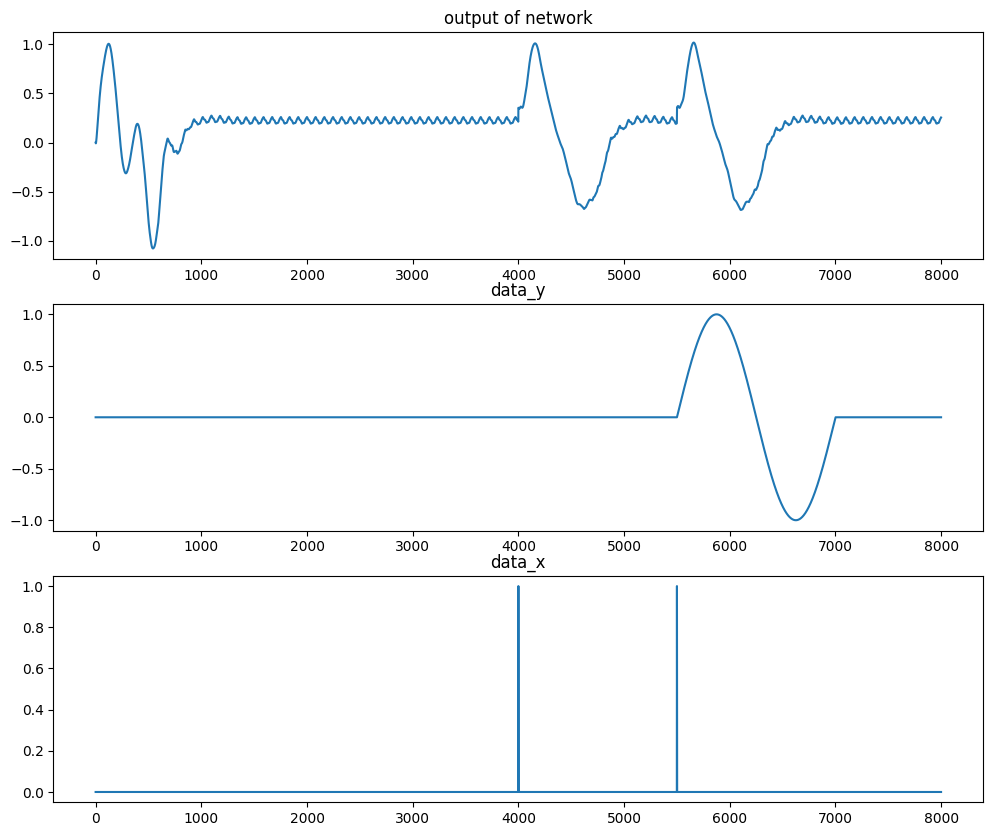

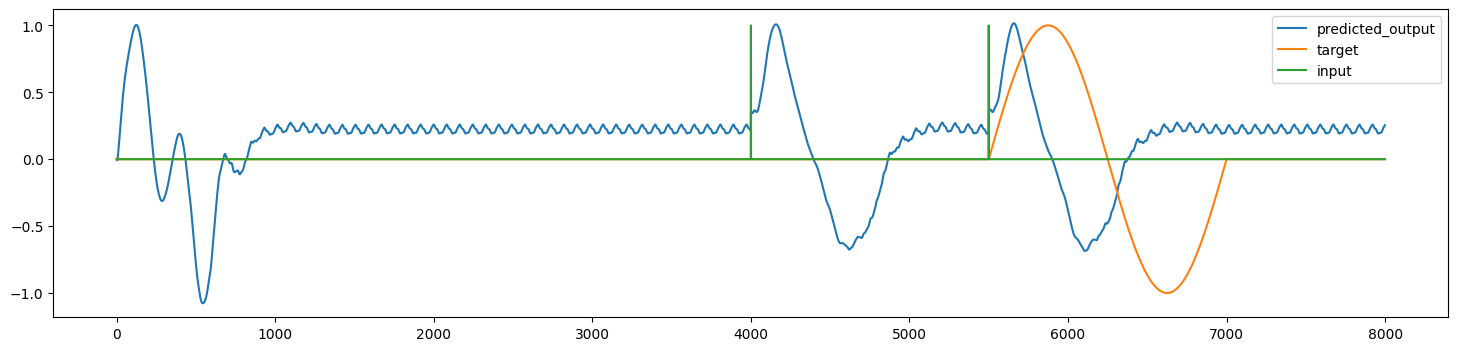

In [5]:
# data
target_shape = 'rectangle'
data_duration = 80
first_cue_time = 40
second_cue_time = 55
target_amplitude = 1
cue_amplitude = 1
dt = 0.01
data_x, data_y, _, _, _ = ready_set_go_forced_generator(target_shape,
                                                        data_duration,
                                                        first_cue_time,
                                                        second_cue_time,
                                                        target_amplitude,
                                                        cue_amplitude,
                                                        dt)
# model
from model.CTRNN import *
from easydict import EasyDict as edict
import yaml
from utils.train_helper import load_model

config_file_path = '/home/matin/McMaster/trimba/phd_codes/CTRNN/experiments/ctrnn_v1/ready_set_go_rectangle/CTRNN_ready_set_go_data_2023-Feb-07-11-09-50_3929231/config.yaml'
config = edict(yaml.full_load(open(config_file_path, 'r')))
config.device = 'cpu'
model = CTRNN(config)
model_file = os.path.join(config.save_dir, config.test.test_model_name)
model_file = model_file.replace('/home/mtnusf97/projects/def-cannoj9/mtnusf97/CTRNN/', '')
load_model(model, model_file, config.device)
model.to('cpu')

activations, hidden_states, outputs = model.init_activations_outputs(batch_size=1)
outputs, activations, hidden_states = model.predict(data_x,
                                                    activations.to(config.device),
                                                    hidden_states.to(config.device),
                                                    outputs)

len_data_points = int(data_duration * (1 / dt))
# plots
x_range = np.arange(len_data_points)
_, axs = plt.subplots(3, 1, figsize=(12,10))
axs[0].plot(x_range, outputs.detach().view(len_data_points))
axs[0].set_title('output of network')
axs[1].plot(x_range, data_y.view(len_data_points))
axs[1].set_title('data_y')
axs[2].plot(x_range, data_x.view(len_data_points))
axs[2].set_title('data_x')

plt.figure(figsize=(18, 4))
plt.plot(x_range, outputs.detach().view(len_data_points), label='predicted_output')
plt.plot(x_range, data_y.view(len_data_points), label='target')
plt.plot(x_range, data_x.view(len_data_points), label='input')
plt.legend()

## test gaussian loss derivative trained model

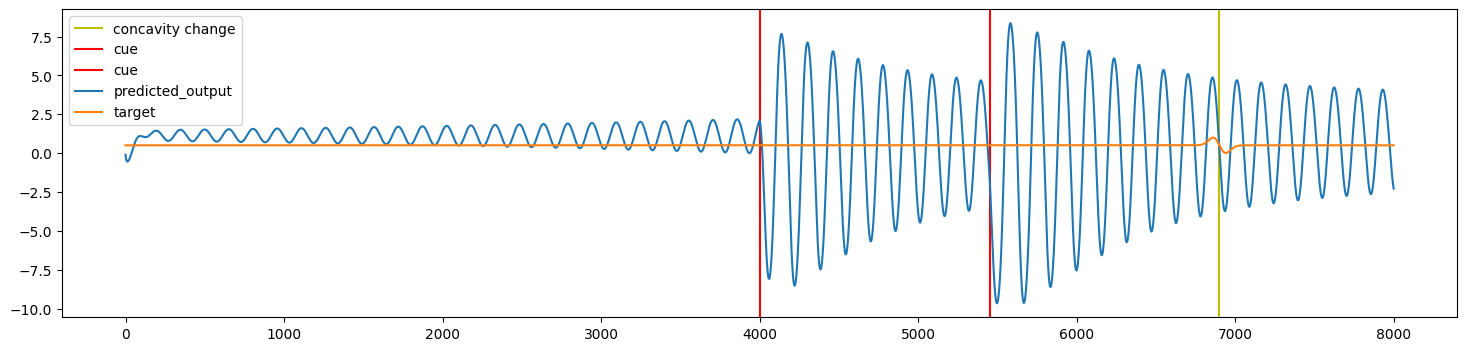

In [25]:
# data
data_duration = 80
first_cue_time = 40
second_cue_time = 54.5
variance = 0.4
scale = 0.99
cue_amplitude = 1
dt = 0.01
data_x, data_y, _, _, concavity_change = gaussian_derivative_loss_forced_generator(data_duration,
                                                                                   first_cue_time,
                                                                                   second_cue_time,
                                                                                   cue_amplitude,
                                                                                   variance,
                                                                                   scale,
                                                                                   dt)

# model
from model.CTRNN import *
from easydict import EasyDict as edict
import yaml
from utils.train_helper import load_model

config_file_path = '/home/matin/McMaster/trimba/phd_codes/CTRNN/experiments/ctrnn_v1/gaussian_derivative_loss_data/CTRNN_gaussian_derivative_loss_data_2023-Feb-07-09-36-09_3912747/config.yaml'
config = edict(yaml.full_load(open(config_file_path, 'r')))
config.device = 'cpu'
model = CTRNN(config)
model_file = os.path.join(config.save_dir, config.test.test_model_name)
model_file = model_file.replace('/home/mtnusf97/projects/def-cannoj9/mtnusf97/CTRNN/', '')
load_model(model, model_file, config.device)
model.to(config.device)

activations, hidden_states, outputs = model.init_activations_outputs(batch_size=1)
outputs, activations, hidden_states = model.predict(data_x,
                                                    activations.to(config.device),
                                                    hidden_states.to(config.device),
                                                    outputs)

# plots
# data_x[0, int(concavity_change/dt)] = 10

len_data_points = int(data_duration * (1 / dt))
x_range = np.arange(len_data_points)
# _, axs = plt.subplots(3, 1, figsize=(12,10))
# axs[0].plot(x_range, outputs.detach().view(len_data_points))
# axs[0].set_title('output of network')
# axs[1].plot(x_range, data_y.view(len_data_points))
# axs[1].set_title('data_y')
# axs[2].plot(x_range, data_x.view(len_data_points))
# axs[2].set_title('data_x')

plt.figure(figsize=(18, 4))
plt.axvline(x = int(concavity_change/dt), color = 'y', label = 'concavity change')
plt.axvline(x = int(first_cue_time/dt), color = 'r', label = 'cue')
plt.axvline(x = int(second_cue_time/dt), color = 'r', label = 'cue')
plt.plot(x_range, outputs.detach().view(len_data_points), label='predicted_output')
plt.plot(x_range, data_y.view(len_data_points), label='target')
# plt.plot(x_range, data_x.view(len_data_points), label='input')
plt.legend()

## ready_set_go data generator

In [1]:
import numpy as np
from dataset_generator.data_generator import *
from utils.other_utils import *
import matplotlib.pyplot as plt
import os

In [13]:
number_of_data_samples = 1000
data_duration = 40
first_cue_first_time = 10
first_cue_last_time = 20
min_interval = 2
max_interval = 8
sine_amplitude = 1
cue_amplitude = 0.3
dt = 0.01

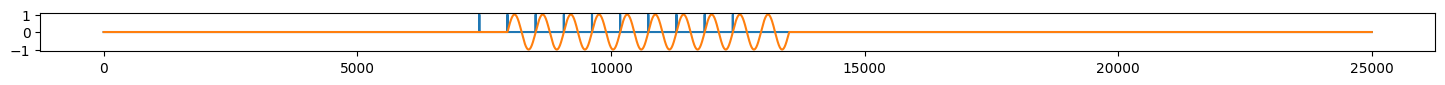

In [8]:
data_x, data_y, first_beat_idx, interval_between_beats, data_y_end_idx = beats_chain_generator(first_beat_first_time=4, first_beat_last_time=10, data_duration=25, target_shape='full_sine', dt= 0.001, number_of_targets=11, number_of_beats=10)
x_range = np.arange(25 / 0.001)
fig = plt.figure(figsize=(18, 0.5))
plt.plot(x_range, torch.flatten(data_x))
plt.plot(x_range, torch.flatten(data_y))

In [14]:
all_data = []
for i in range(number_of_data_samples):
    data_x, data_y, first_beat_idx, interval_between_beats, data_y_end_idx = beats_chain_generator(first_beat_first_time=4, first_beat_last_time=10, data_duration=25, target_shape='half_sine')
    data = {'data_x': data_x,
            'data_y': data_y,
            'first_beat_idx': first_beat_idx,
            'interval_between_beats': interval_between_beats,
            'data_y_end_idx': data_y_end_idx,
            'dt': dt}

    all_data.append(data)

In [15]:
path_to_save = '/home/matin/trimba/phd_codes/ctrnn_pytorch/generated_datasets'
data_name = 'ready_set_go_samples_1000_duration_40_dt01_cue_f10_l20_interval_2_8_sa1_cuea3e-1'
save(path_to_save, data_name, all_data)

1

# test beats chain generator script

In [9]:
def load(path_to_file):
    with open(path_to_file, 'rb') as file:
        rnn_params = pickle.load(file)
    return rnn_params


In [10]:
data = load('/home/matin/McMaster/trimba/phd_codes/CTRNN/generated_datasets/beats_chain_generator_100_duration25_dt0.001_beat_f4l10_interval_0.4_1.2_targeta1_beatsa1_targetshapefull_sine_beatsn10_targetsn11.pkl')

In [11]:
data[0]

{'data_x': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'data_y': tensor([[0., 0., 0.,  ..., 0., 0., 0.]]),
 'first_beat_idx': 5700,
 'interval_between_beats': 0.4966506530312246,
 'data_y_end_idx': 11163,
 'dt': 0.001}

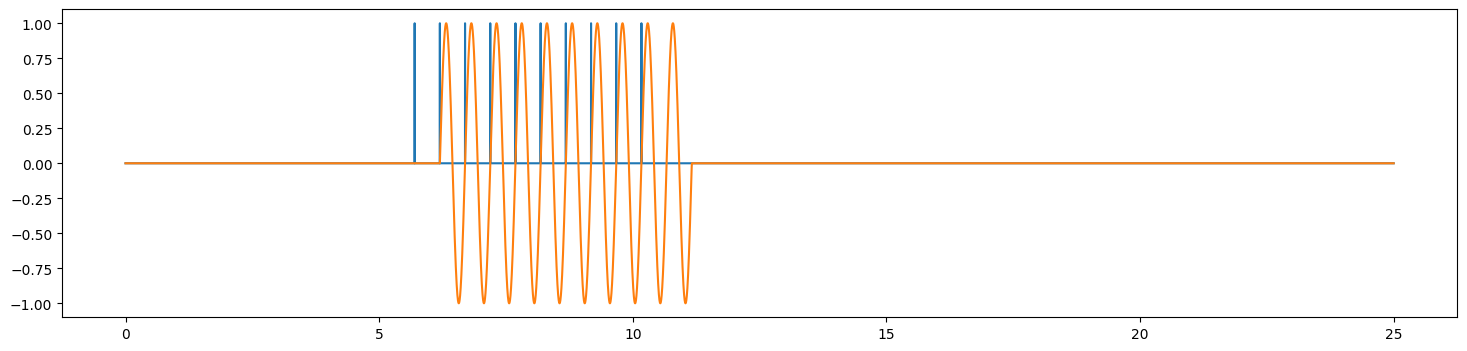

In [15]:
x_range = np.arange(0, 25, 0.001)
fig = plt.figure(figsize=(18,4))
plt.plot(x_range, torch.flatten(data[0]['data_x']))
plt.plot(x_range, torch.flatten(data[0]['data_y']))

## test beats chain trained model

In [3]:
# data
data_duration = 35
dt  = 0.01
f_beat_time = 4
interval = 0.4
n_of_targets = 5
n_of_beats = 5
target_shape = 'full_sine'
data_x, data_y, first_beat_idx, _, _ = beats_chain_forced_generator(number_of_beats=n_of_beats,
                                                                    number_of_targets=n_of_targets,
                                                                    target_starts_from_beat=2,
                                                                    target_shape=target_shape,
                                                                    data_duration=data_duration,
                                                                    first_beat_time=f_beat_time,
                                                                    interval=interval,
                                                                    target_amplitude=1,
                                                                    beats_amplitude=1,
                                                                    dt=dt)


# model
from model.CTRNN import *
from easydict import EasyDict as edict
import yaml
from utils.train_helper import load_model

config_file_path = '/home/matin/McMaster/trimba/phd_codes/CTRNN/experiments/ctrnn_v2/beats_chain/CTRNN_beats_chain_full_sine_beatsn10_targetsn10_dt0.01_2023-Feb-13-00-20-33_2965118/config.yaml'
config = edict(yaml.full_load(open(config_file_path, 'r')))
config.device = 'cpu'
model = CTRNN(config)
model_file = os.path.join(config.save_dir, config.test.test_model_name)
model_file = model_file.replace('/home/mtnusf97/projects/def-cannoj9/mtnusf97/CTRNN/', '')
load_model(model, model_file, config.device)
model.to(config.device)
activations, hidden_states, outputs = model.init_activations_outputs(batch_size=1)
outputs, activations, hidden_states = model.predict(data_x,
                                                    activations.to(config.device),
                                                    hidden_states.to(config.device),
                                                    outputs)

last_index = int((f_beat_time + (n_of_targets + 3) * interval) / dt)
first_index = int((f_beat_time - interval) / dt)

# plots
len_data_points = int(data_duration * (1 / dt))
x_range = np.arange(len_data_points)
_, axs = plt.subplots(3, 1, figsize=(12,10))
axs[0].plot(x_range[first_index:last_index], outputs.detach().view(len_data_points)[first_index:last_index])
axs[0].set_title('output of network')
axs[1].plot(x_range[first_index:last_index], data_y.view(len_data_points)[first_index:last_index])
axs[1].set_title('data_y')
axs[2].plot(x_range[first_index:last_index], data_x.view(len_data_points)[first_index:last_index])
axs[2].set_title('data_x')

plt.figure(figsize=(25, 10))
plt.plot(x_range[first_index:last_index], outputs.detach().view(len_data_points)[first_index:last_index], label='predicted_output')
plt.plot(x_range[first_index:last_index], data_y.view(len_data_points)[first_index:last_index], label='target')
plt.plot(x_range[first_index:last_index], data_x.view(len_data_points)[first_index:last_index], label='input')
plt.legend()

## test beats chain derivative trained model with mixed data_x

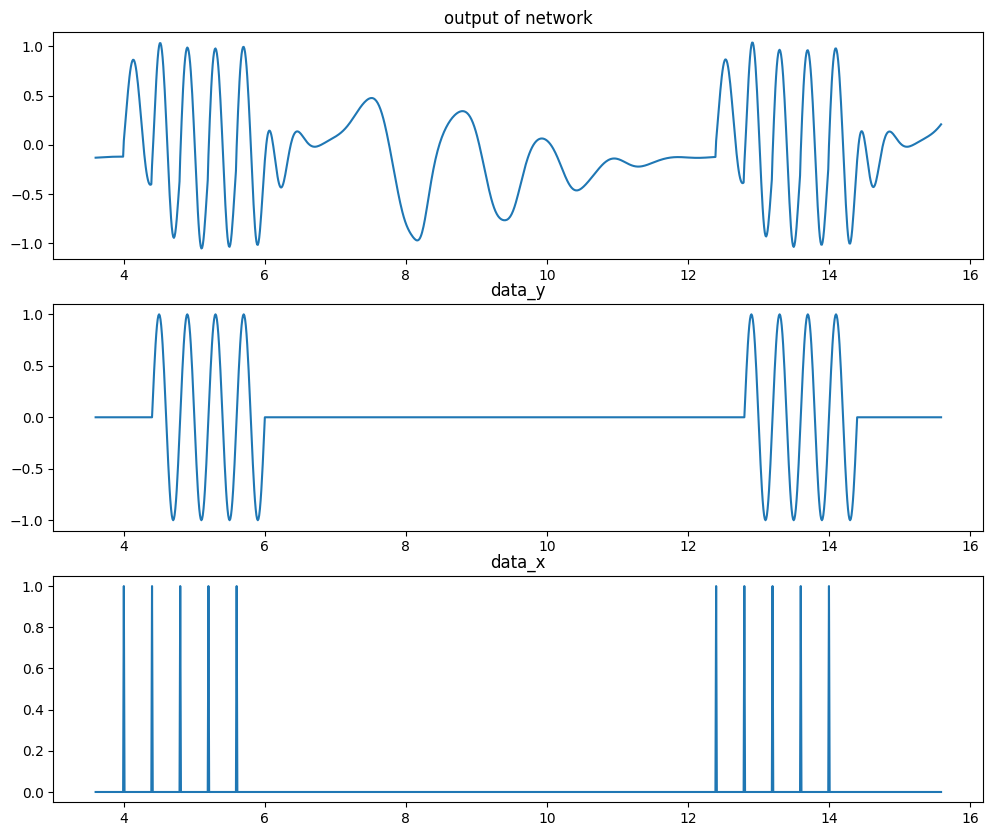

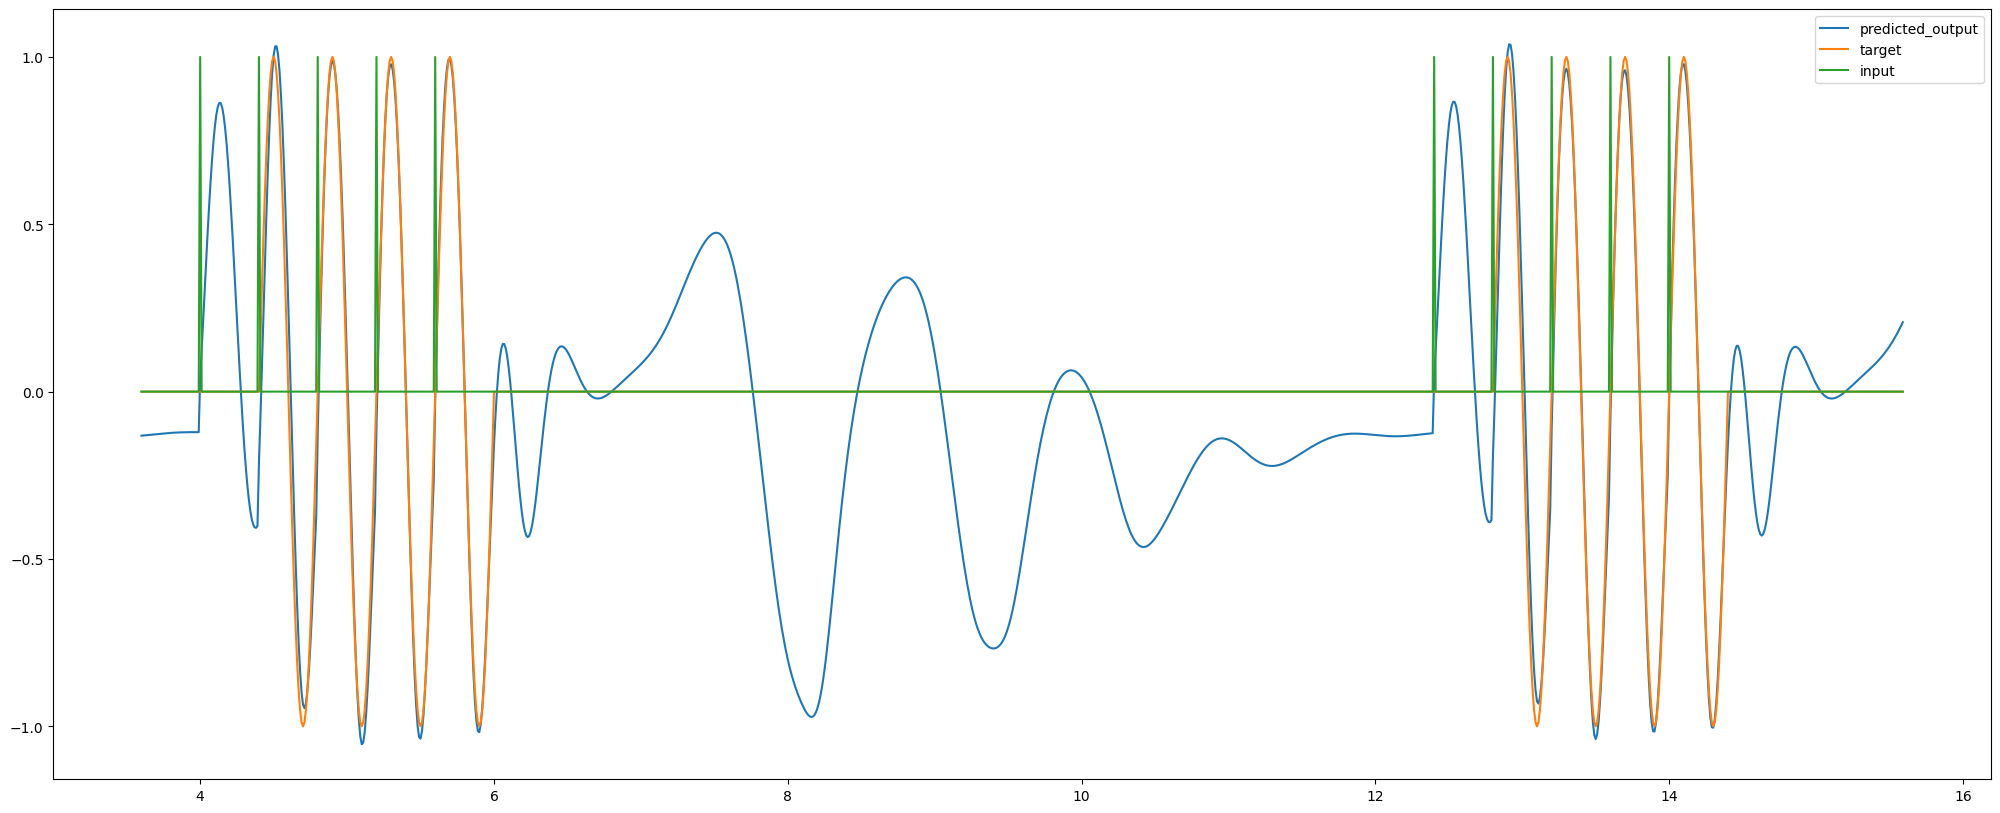

In [28]:
# data
data_duration = 50
dt  = 0.01
f_beat_time1 = 4
interval1 = 0.4
n_of_targets1 = 5
n_of_beats1 = 5
target_shape = 'full_sine'
data_x1, data_y1, first_beat_idx, _, data_y_end_idx = beats_chain_forced_generator(number_of_beats=n_of_beats1,
                                                                    number_of_targets=n_of_targets1,
                                                                    target_starts_from_beat=2,
                                                                    target_shape=target_shape,
                                                                    data_duration=data_duration,
                                                                    first_beat_time=f_beat_time1,
                                                                    interval=interval1,
                                                                    target_amplitude=1,
                                                                    beats_amplitude=1,
                                                                    dt=dt)

distance_between_chains = 6
f_beat_time2 = data_y_end_idx * dt + interval1 + distance_between_chains
interval2 = 0.4
n_of_targets2 = 5
n_of_beats2 = 5


data_x2, data_y2, first_beat_idx, _, _ = beats_chain_forced_generator(number_of_beats=n_of_beats2,
                                                                    number_of_targets=n_of_targets2,
                                                                    target_starts_from_beat=2,
                                                                    target_shape=target_shape,
                                                                    data_duration=data_duration,
                                                                    first_beat_time=f_beat_time2,
                                                                    interval=interval2,
                                                                    target_amplitude=1,
                                                                    beats_amplitude=1,
                                                                    dt=dt)

data_x = data_x1 + data_x2
data_y = data_y1 + data_y2


config_file_path = '/home/matin/McMaster/trimba/phd_codes/CTRNN/experiments/ctrnn_v2/beats_chain/CTRNN_beats_chain_full_sine_beatsn10_targetsn10_dt0.01_2023-Feb-13-00-20-33_2965118/config.yaml'
config = edict(yaml.full_load(open(config_file_path, 'r')))
config.device = 'cpu'
model = CTRNN(config)
model_file = os.path.join(config.save_dir, config.test.test_model_name)
model_file = model_file.replace('/home/mtnusf97/projects/def-cannoj9/mtnusf97/CTRNN/', '')
load_model(model, model_file, config.device)
model.to(config.device)
activations, hidden_states, outputs = model.init_activations_outputs(batch_size=1)
outputs, activations, hidden_states = model.predict(data_x,
                                                    activations.to(config.device),
                                                    hidden_states.to(config.device),
                                                    outputs)

last_index = int((f_beat_time2 + (n_of_targets2 + 3) * interval2) / dt)
first_index = int((f_beat_time1 - interval1) / dt)

# plots
len_data_points = int(data_duration * (1 / dt))
x_range = np.arange(len_data_points) * dt
_, axs = plt.subplots(3, 1, figsize=(12,10))
axs[0].plot(x_range[first_index:last_index], outputs.detach().view(len_data_points)[first_index:last_index])
axs[0].set_title('output of network')
axs[1].plot(x_range[first_index:last_index], data_y.view(len_data_points)[first_index:last_index])
axs[1].set_title('data_y')
axs[2].plot(x_range[first_index:last_index], data_x.view(len_data_points)[first_index:last_index])
axs[2].set_title('data_x')

plt.figure(figsize=(25, 10))
plt.plot(x_range[first_index:last_index], outputs.detach().view(len_data_points)[first_index:last_index], label='predicted_output')
plt.plot(x_range[first_index:last_index], data_y.view(len_data_points)[first_index:last_index], label='target')
plt.plot(x_range[first_index:last_index], data_x.view(len_data_points)[first_index:last_index], label='input')
plt.legend()

# error plots of mixed beat chains

In [0]:
config_file_path = '/home/matin/McMaster/trimba/phd_codes/CTRNN/experiments/ctrnn_v2/beats_chain/CTRNN_beats_chain_full_sine_beatsn10_targetsn10_dt0.01_2023-Feb-13-00-20-33_2965118/config.yaml'
config = edict(yaml.full_load(open(config_file_path, 'r')))
config.device = 'cpu'
model = CTRNN(config)
model_file = os.path.join(config.save_dir, config.test.test_model_name)
model_file = model_file.replace('/home/mtnusf97/projects/def-cannoj9/mtnusf97/CTRNN/', '')
load_model(model, model_file, config.device)
model.to(config.device)

In [21]:
distance_between_chains = np.arange(0, 40, 0.1)
errors_array_4 = []

for distance in tqdm(distance_between_chains):
    error = mixed_data_x_loss(
        model,
        data_duration=19 + distance,
        first_beat_time1=10,
        distance_between_chains=distance,
        interval1=0.4,
        interval2=0.4,
        number_of_beats1=10,
        number_of_beats2=10,
        number_of_targets1=10,
        number_of_targets2=10
        )
    errors_array_4.append(error)

100%|██████████| 400/400 [07:09<00:00,  1.07s/it]


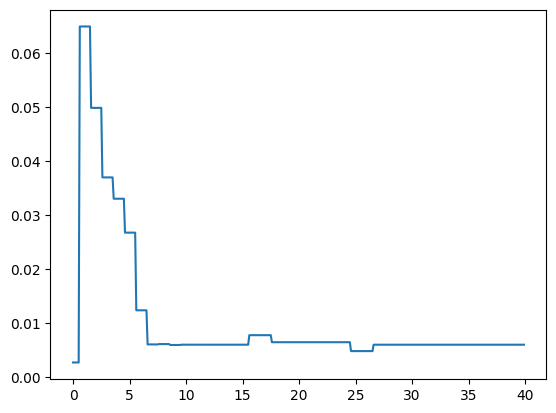

In [32]:
plt.plot(distance_between_chains, errors_array_4)

In [38]:
distance_between_chains = np.arange(0, 20, 0.1)
errors_array_8 = []

for distance in tqdm(distance_between_chains):
    error = mixed_data_x_loss(
        model,
        data_duration=28 + distance,
        first_beat_time1=10,
        distance_between_chains=distance,
        interval1=0.8,
        interval2=0.8,
        number_of_beats1=10,
        number_of_beats2=10,
        number_of_targets1=10,
        number_of_targets2=10
        )
    errors_array_8.append(error)

100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


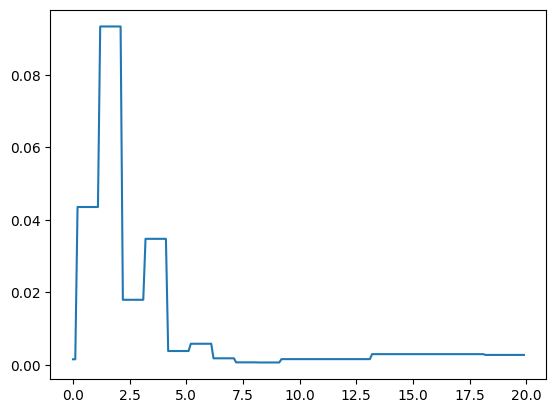

In [40]:
plt.plot(distance_between_chains, errors_array_8)

In [46]:
distance_between_chains = np.arange(0, 20, 0.1)
errors_array_12 = []

for distance in tqdm(distance_between_chains):
    error = mixed_data_x_loss(
        model,
        data_duration=37 + distance,
        first_beat_time1=10,
        distance_between_chains=distance,
        interval1=1.2,
        interval2=1.2,
        number_of_beats1=10,
        number_of_beats2=10,
        number_of_targets1=10,
        number_of_targets2=10
        )
    errors_array_12.append(error)

100%|██████████| 200/200 [04:52<00:00,  1.46s/it]


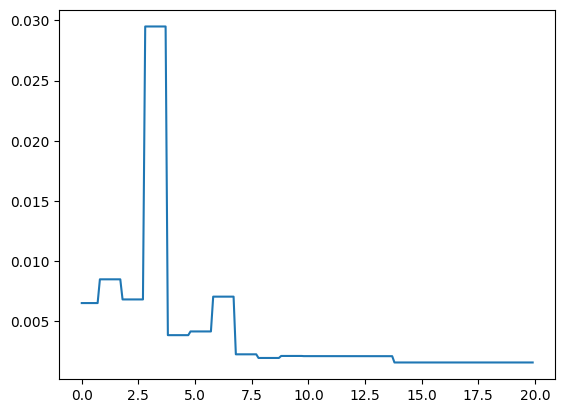

In [47]:
plt.plot(distance_between_chains, errors_array_12)

In [51]:
distance_between_chains = np.arange(0, 20, 0.1)
errors_array_4_8 = []

for distance in tqdm(distance_between_chains):
    error = mixed_data_x_loss(
        model,
        data_duration=24 + distance,
        first_beat_time1=10,
        distance_between_chains=distance,
        interval1=0.4,
        interval2=0.8,
        number_of_beats1=10,
        number_of_beats2=10,
        number_of_targets1=10,
        number_of_targets2=10
        )
    errors_array_4_8.append(error)

100%|██████████| 200/200 [03:07<00:00,  1.07it/s]


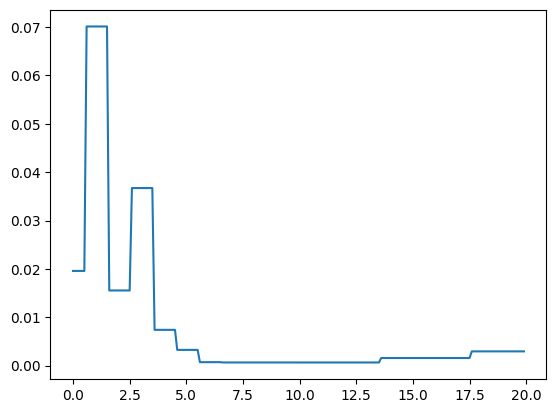

In [52]:
plt.plot(distance_between_chains, errors_array_4_8)

In [60]:
np.argmin(errors_array_12)

138

In [74]:
print(np.argmin(errors_array_4[25:70]) + 25)
print(np.argmin(errors_array_8[25:70]) + 25)
print(np.argmin(errors_array_12[25:70]) + 25)
print(np.argmin(errors_array_4_8[25:70]) + 25)
print(np.argmin(errors_array_4_12[25:70]) + 25)

66
62
68
66
56


In [73]:
distance_between_chains = np.arange(0, 20, 0.1)
errors_array_4_12 = []

for distance in tqdm(distance_between_chains):
    error = mixed_data_x_loss(
        model,
        data_duration=28 + distance,
        first_beat_time1=10,
        distance_between_chains=distance,
        interval1=0.4,
        interval2=1.2,
        number_of_beats1=10,
        number_of_beats2=10,
        number_of_targets1=10,
        number_of_targets2=10
        )
    errors_array_4_12.append(error)

100%|██████████| 200/200 [04:07<00:00,  1.24s/it]


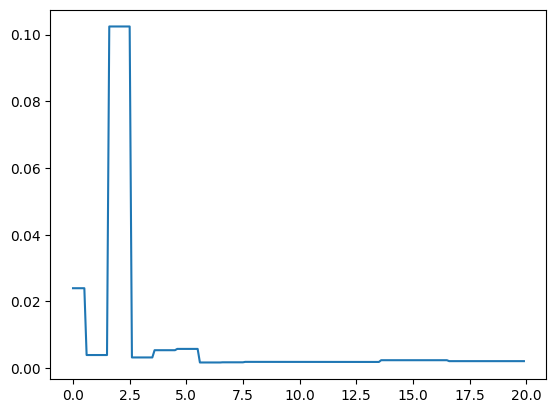

In [75]:
plt.plot(distance_between_chains, errors_array_4_12)
